In [ ]:
# Imports and data load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# For reproducibility
RANDOM_STATE = 42

# Load dataset
geyser = sns.load_dataset('geyser')
geyser = geyser[['duration', 'waiting']].dropna().reset_index(drop=True)
X = geyser[['duration', 'waiting']].values
N, D = X.shape
print(f"Loaded Old Faithful dataset: N={N}, D={D}")

geyser.head()

Loaded Old Faithful dataset: N=272, D=2


,duration,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


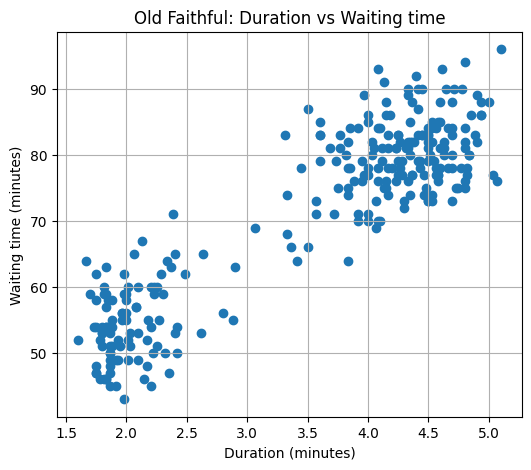

In [ ]:
# Scatter plot: waiting time vs eruption time
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1])
plt.xlabel('Duration (minutes)')
plt.ylabel('Waiting time (minutes)')
plt.title('Old Faithful: Duration vs Waiting time')
plt.grid(True)
plt.show()

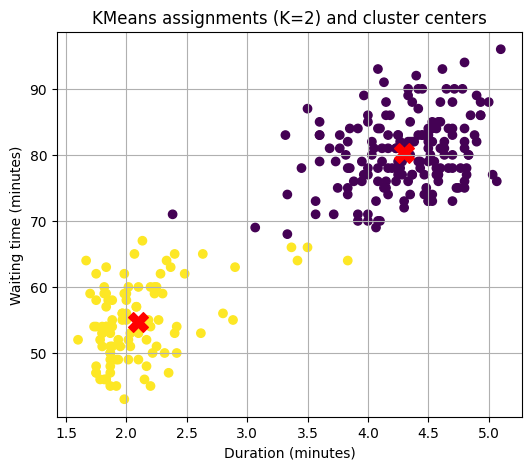

KMeans centers:
[[ 4.29793023 80.28488372]
 [ 2.09433    54.75      ]]


In [ ]:
# KMeans initialization with K=2
K = 2
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X)
kmeans_labels = kmeans.labels_
kmeans_centers = kmeans.cluster_centers_

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=kmeans_labels, cmap='viridis')
plt.scatter(kmeans_centers[:,0], kmeans_centers[:,1], marker='X',c='r', s=200, edgecolor='r', linewidth=1)
plt.xlabel('Duration (minutes)')
plt.ylabel('Waiting time (minutes)')
plt.title('KMeans assignments (K=2) and cluster centers')
plt.grid(True)
plt.show()

print('KMeans centers:')
print(kmeans_centers)

In [ ]:
# Initialize GMM parameters as per provided algorithm
eps = 1e-6
# responsibilities initial from KMeans hard assignments
pi = np.zeros(K)
mu = np.zeros((K, D))
sigma = np.zeros((K, D, D))
N_k = np.zeros(K)

for k in range(K):
    members = X[kmeans_labels == k]
    N_k[k] = members.shape[0]
    pi[k] = N_k[k] / N
    mu[k] = members.mean(axis=0)
    # covariance of cluster
    if members.shape[0] > 1:
        sigma[k] = np.cov(members.T) + eps * np.eye(D)
    else:
        sigma[k] = np.eye(D)

print('Initial pi:', pi)
print('Initial mu:\n', mu)
print('Initial sigma:\n', sigma)

Initial pi: [0.63235294 0.36764706]
Initial mu:
 [[ 4.29793023 80.28488372]
 [ 2.09433    54.75      ]]
Initial sigma:
 [[[ 0.17865687  0.76756385]
  [ 0.76756385 31.66690566]]

 [[ 0.15583807  0.99561869]
  [ 0.99561869 34.75505151]]]


In [ ]:
from scipy.stats import multivariate_normal

def gaussian_pdf(x, mean, cov):
    return multivariate_normal.pdf(x, mean=mean, cov=cov)

# EM algorithm implementation
max_iters = 200
tol = 1e-3
log_likelihoods = []

pi_t = pi.copy()
mu_t = mu.copy()
sigma_t = sigma.copy()

for it in range(max_iters):
    # E-step: responsibilities r_ik
    r = np.zeros((N, K))
    for k in range(K):
        r[:, k] = pi_t[k] * multivariate_normal.pdf(X, mean=mu_t[k], cov=sigma_t[k])
    # normalize
    r_sum = r.sum(axis=1, keepdims=True)
    r_sum[r_sum == 0] = 1e-12
    r = r / r_sum

    # M-step
    N_k_t = r.sum(axis=0)
    pi_new = N_k_t / N
    mu_new = (r.T @ X) / N_k_t[:, None]
    sigma_new = np.zeros_like(sigma_t)
    for k in range(K):
        X_centered = X - mu_new[k]
        weighted = (r[:, k][:, None] * X_centered).T @ X_centered
        sigma_new[k] = weighted / N_k_t[k] + eps * np.eye(D)

    # compute log-likelihood
    ll = 0.0
    for i in range(N):
        s = 0.0
        for k in range(K):
            s += pi_new[k] * multivariate_normal.pdf(X[i], mean=mu_new[k], cov=sigma_new[k])
        ll += np.log(s + 1e-12)
    log_likelihoods.append(ll)

    # check convergence
    if it > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
        print(f"Converged at iteration {it}")
        pi_t, mu_t, sigma_t = pi_new, mu_new, sigma_new
        break

    pi_t, mu_t, sigma_t = pi_new, mu_new, sigma_new
else:
    print('Reached max iterations')

print('Final pi:', pi_t)
print('Final mu:\n', mu_t)

# store final responsibilities for visualization
final_r = r


Converged at iteration 4
Final pi: [0.64411387 0.35588613]
Final mu:
 [[ 4.28969054 79.96846057]
 [ 2.03642076 54.47884155]]


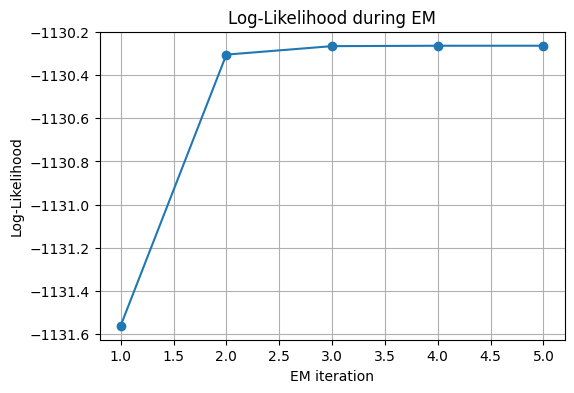

In [ ]:
# Plot log-likelihood over EM iterations
plt.figure(figsize=(6,4))
plt.plot(range(1, len(log_likelihoods)+1), log_likelihoods, marker='o')
plt.xlabel('EM iteration')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood during EM')
plt.grid(True)
plt.show()

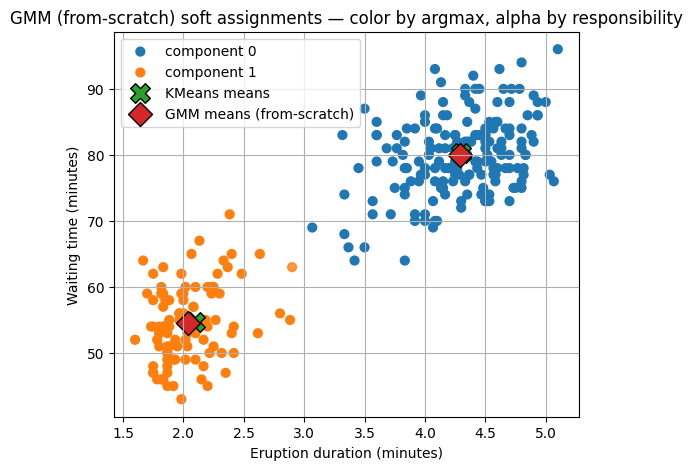

In [ ]:
# Visualize soft cluster assignment: color = argmax responsibility, alpha = responsibility of assigned component
assigned = np.argmax(final_r, axis=1)
assigned_resp = final_r[np.arange(N), assigned]

plt.figure(figsize=(6,5))
for k in range(K):
    idx = (assigned == k)
    plt.scatter(X[idx,0], X[idx,1], s=40, alpha=assigned_resp[idx], label=f'component {k}')

plt.scatter(kmeans_centers[:,0], kmeans_centers[:,1], marker='X', s=200, edgecolor='k', linewidth=1, label='KMeans means')
plt.scatter(mu_t[:,0], mu_t[:,1], marker='D', s=150, edgecolor='k', linewidth=1, label='GMM means (from-scratch)')

plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Waiting time (minutes)')
plt.title('GMM (from-scratch) soft assignments — color by argmax, alpha by responsibility')
plt.legend()
plt.grid(True)
plt.show()

[1.         1.         0.99999135 0.99998949 1.         0.99281035
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         0.99999996 0.99999996 1.
 1.         1.         1.         1.         0.99999987 0.98467599
 1.         1.         0.99999999 1.         1.         1.
 1.         1.         0.99990859 1.         1.         0.99999999
 1.         1.         0.99999998 1.         1.         0.99999998
 1.         0.99999999 1.         0.99999963 1.         0.99999997
 1.         0.99999989 1.         1.         1.         1.
 1.         1.         1.         0.99999995 1.         1.
 0.99999841 1.         1.         1.         0.99999997 1.
 1.         1.         0.9999972  1.         1.         0.99999998
 1.         1.         0.99999968 1.         0.9999998  1.
 1.         1.         1.         1.         1.         0.99438059
 1.         1.         1.         1.         0.99999999 1.
 0.99999839 1.         1.         1.         0.99999988 1.


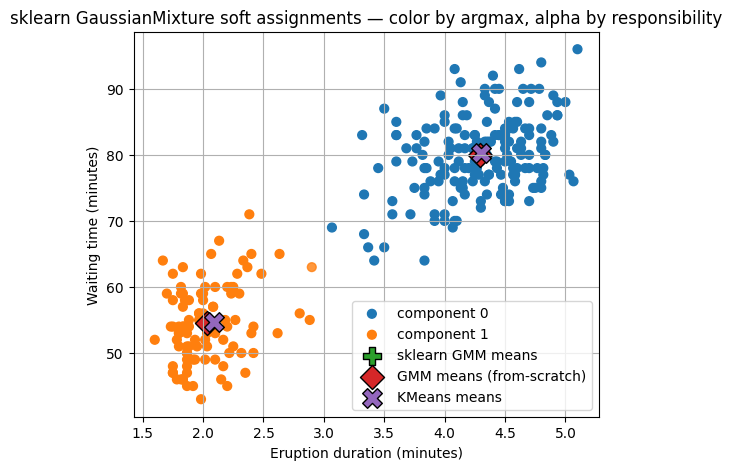

sklearn GMM means:
 [[ 4.28977944 79.96953298]
 [ 2.03652149 54.47986018]]

From-scratch GMM means:
 [[ 4.28969054 79.96846057]
 [ 2.03642076 54.47884155]]


In [ ]:
# Run sklearn's GaussianMixture for comparison
gmm_sklearn = GaussianMixture(n_components=K, covariance_type='full', init_params='kmeans', random_state=RANDOM_STATE)
gmm_sklearn.fit(X)

sk_resp = gmm_sklearn.predict_proba(X)
sk_assigned = np.argmax(sk_resp, axis=1)
sk_assigned_resp = sk_resp[np.arange(N), sk_assigned]
print(sk_assigned_resp)

plt.figure(figsize=(6,5))
for k in range(K):
    idx = (sk_assigned == k)
    plt.scatter(X[idx,0], X[idx,1], s=40, alpha=sk_assigned_resp[idx], label=f'component {k}')

sk_means = gmm_sklearn.means_
plt.scatter(sk_means[:,0], sk_means[:,1], marker='P', s=150, edgecolor='k', linewidth=1, label='sklearn GMM means')
plt.scatter(mu_t[:,0], mu_t[:,1], marker='D', s=150, edgecolor='k', linewidth=1, label='GMM means (from-scratch)')
plt.scatter(kmeans_centers[:,0], kmeans_centers[:,1], marker='X', s=200, edgecolor='k', linewidth=1, label='KMeans means')

plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Waiting time (minutes)')
plt.title('sklearn GaussianMixture soft assignments — color by argmax, alpha by responsibility')
plt.legend()
plt.grid(True)
plt.show()

print('sklearn GMM means:\n', sk_means)
print('\nFrom-scratch GMM means:\n', mu_t)

In [ ]:
# Numeric comparison of means (pair the components by nearest mean)
from scipy.spatial.distance import cdist

dist = cdist(mu_t, sk_means)
print('Pairwise distances between from-scratch means (rows) and sklearn means (cols):\n', dist)

pairs = dist.argmin(axis=1)
for i, j in enumerate(pairs):
    print(f'from-scratch mean {i} matches sklearn mean {j} with distance {dist[i,j]:.6f}')

Pairwise distances between from-scratch means (rows) and sklearn means (cols):
 [[1.07609158e-03 2.55879956e+01]
 [2.55900952e+01 1.02359347e-03]]
from-scratch mean 0 matches sklearn mean 0 with distance 0.001076
from-scratch mean 1 matches sklearn mean 1 with distance 0.001024


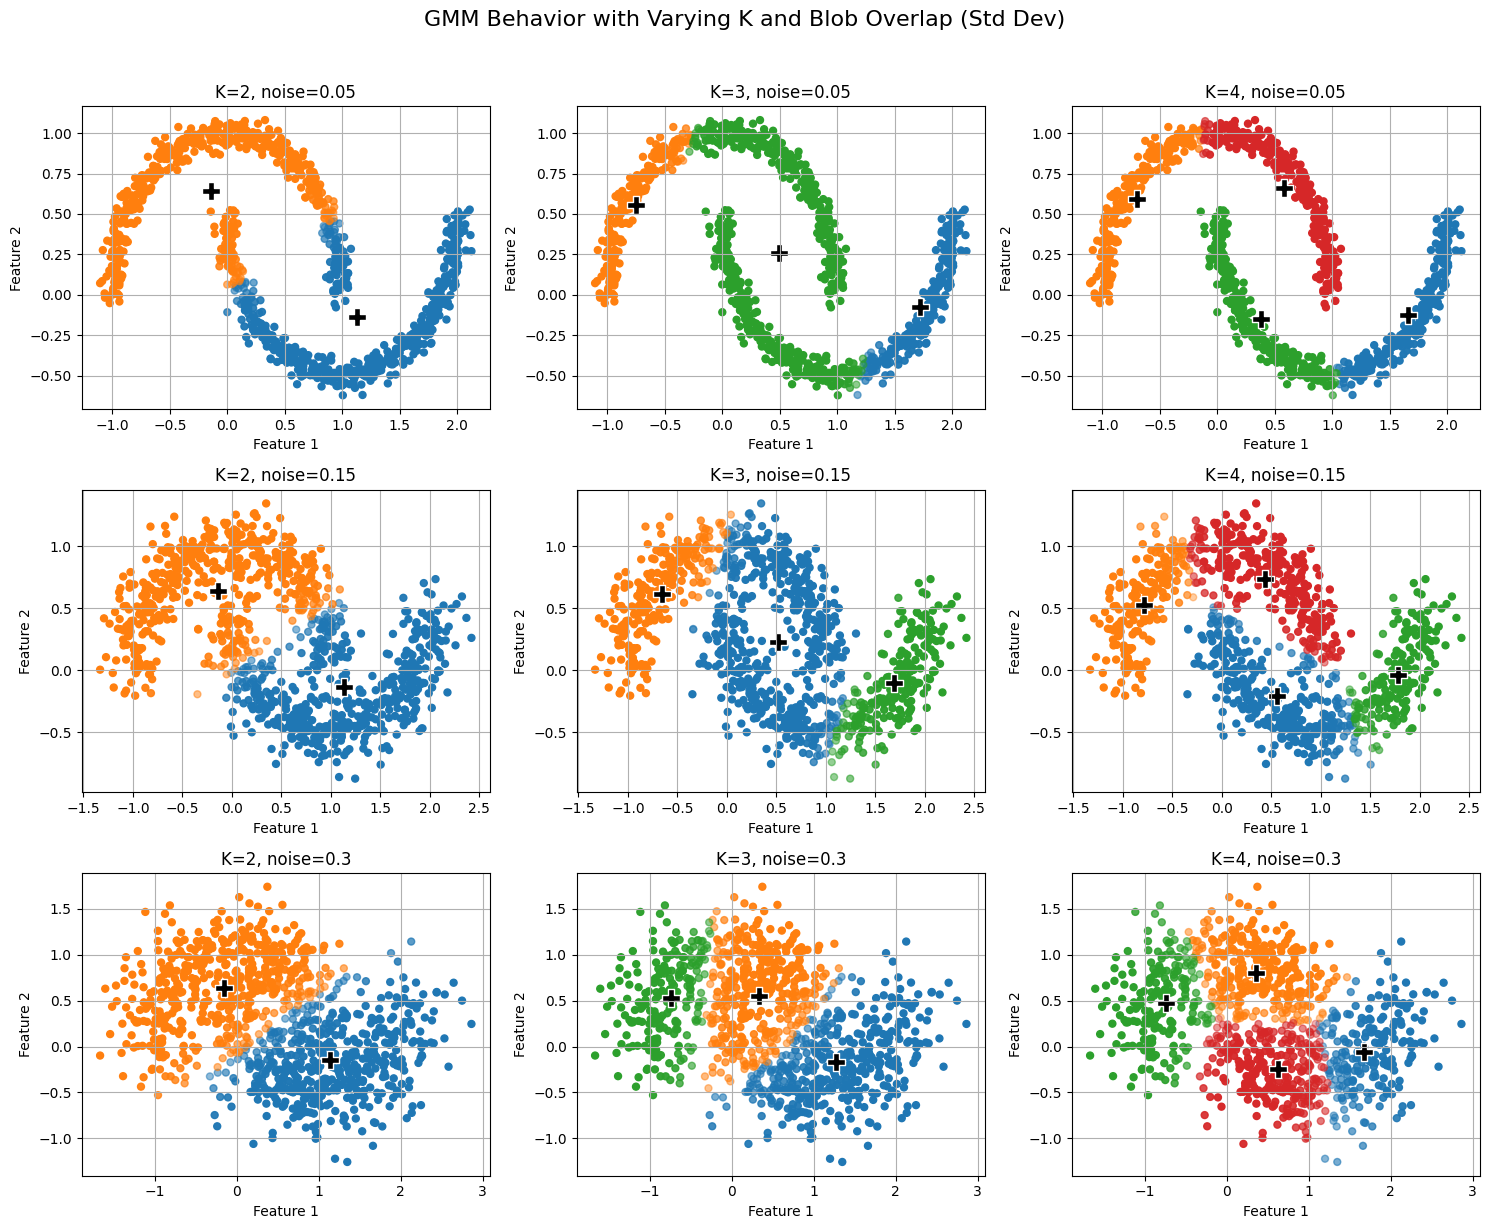

In [ ]:
# ==============================================================
# GMM Behavior Visualization on Overlapping Blobs
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.mixture import GaussianMixture

# Parameters
random_state = 42
n_samples = 1000
K_values = [2, 3, 4]             # different numbers of GMM components
std_values = [0.3, 0.7, 1.2]     # different std deviations (overlap control)
noise_values = [0.05, 0.15, 0.3]
ncols = len(K_values)
nrows = len(std_values)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
fig.suptitle("GMM Behavior with Varying K and Blob Overlap (Std Dev)", fontsize=16, y=1.02)

for i, noise in enumerate(noise_values):
    # Generate synthetic dataset with controlled overlap

    # X, y_true = make_blobs(
    #     n_samples=n_samples,
    #     centers=3,
    #     cluster_std=std,
    #     random_state=random_state
    # )

    # Generate dataset
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)

    for j, K in enumerate(K_values):
        ax = axes[i, j]

        # Fit GMM
        gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=random_state)
        gmm.fit(X)
        resp = gmm.predict_proba(X)
        assigned = np.argmax(resp, axis=1)
        assigned_resp = resp[np.arange(len(X)), assigned]

        # Plot data with transparency proportional to responsibility
        for k in range(K):
            idx = (assigned == k)
            ax.scatter(
                X[idx, 0],
                X[idx, 1],
                s=25,
                alpha=assigned_resp[idx],
                label=f'Component {k}'
            )

        # Plot GMM means
        means = gmm.means_
        ax.scatter(means[:, 0], means[:, 1], c='black', s=150, marker='P', label='GMM means', edgecolor='white')

        ax.set_title(f"K={K}, noise={noise}")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================
# Adaptive GMM: Termination based on max Gaussian probability (not responsibility)
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal

# 1️⃣ Generate a complex dataset (moons + noise)
np.random.seed(42)
X_moons, _ = make_moons(n_samples=600, noise=0.12, random_state=42)
noise = np.random.uniform(low=-2, high=3, size=(120, 2))
X = np.vstack([X_moons]) #noise

# 2️⃣ Parameters
prob_threshold = 0.02   # minimum probability density threshold per point
max_K = 50
start_K = 2
models = []
criteria_met = False

print("Starting adaptive GMM fitting (probability-based termination)...")

# 3️⃣ Adaptive loop over K
for K in range(start_K, max_K + 1):
    gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=42)
    gmm.fit(X)

    # Compute per-component probabilities p(x|k)
    probs = np.zeros((X.shape[0], K))
    for k in range(K):
        probs[:, k] = gmm.weights_[k] * multivariate_normal.pdf(
            X, mean=gmm.means_[k], cov=gmm.covariances_[k]
        )

    max_probs = np.max(probs, axis=1)
    # print(max_probs.shape)
    min_prob_value = np.min(max_probs)
    models.append((K, gmm, min_prob_value))
    print(f"K={K:2d} → min(max p(x|k)) = {min_prob_value:.5f}")

    # Termination condition
    if min_prob_value >= prob_threshold:
        ideal_K = K
        criteria_met = True
        break

if not criteria_met:
    ideal_K = max_K
    print(f"⚠️  Criteria not met up to K={max_K}. Using K={max_K} as fallback.")
else:
    print(f"\n✅ Ideal K found = {ideal_K} (min max prob = {min_prob_value:.5f})")

# 4️⃣ Visualization grid of cluster assignments for each K
ncols = 3
nrows = int(np.ceil(len(models) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
fig.suptitle(f"Adaptive GMM: Increasing K until p(x|k) ≥ {prob_threshold} for all points",
             fontsize=14, y=1.02)

for idx, (K, gmm, min_p) in enumerate(models):
    ax = axes.flat[idx]
    resp = gmm.predict_proba(X)
    assigned = np.argmax(resp, axis=1)

    # Compute max probabilities for alpha transparency
    probs = np.zeros((X.shape[0], K))
    for k in range(K):
        probs[:, k] = gmm.weights_[k] * multivariate_normal.pdf(
            X, mean=gmm.means_[k], cov=gmm.covariances_[k]
        )
    max_probs = np.max(probs, axis=1)

    # Plot clusters
    for k in range(K):
        mask = (assigned == k)
        ax.scatter(X[mask, 0], X[mask, 1], s=25, alpha=np.clip(max_probs[mask] / max_probs.max(), 0.2, 1.0))

    means = gmm.means_
    ax.scatter(means[:, 0], means[:, 1], c='black', marker='P', s=150, edgecolor='white')
    ax.set_title(f"K={K}, min max p={min_p:.4f}")
    ax.grid(True)

# Hide unused subplots
for ax in axes.flat[len(models):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# 5️⃣ Plot min(max p(x|k)) vs K
plt.figure(figsize=(7,4))
Ks = [m[0] for m in models]
min_prob_values = [m[2] for m in models]
plt.plot(Ks, min_prob_values, marker='o', linewidth=2)
plt.axhline(prob_threshold, color='r', linestyle='--', label=f"Threshold = {prob_threshold}")
plt.axvline(ideal_K, color='g', linestyle='--', label=f"Ideal K = {ideal_K}")
plt.title("Min(Max p(x|k)) vs Number of Components (K)")
plt.xlabel("K (Number of Components)")
plt.ylabel("Min(Max Probability Density)")
plt.legend()
plt.grid(True)
plt.show()

# 6️⃣ Final summary
print("\n=== Adaptive GMM Summary ===")
for K, _, minp in models:
    print(f"K={K:2d} → min(max p(x|k)) = {minp:.6f}")
print(f"\n✅ Ideal K = {ideal_K}  (threshold = {prob_threshold})")


Interactive Demos:
1. [Demo 1](https://github.com/ChenTaHung/GMM-Visualization)
2. [Demo 2](https://lukapopijac.github.io/gaussian-mixture-model/)

# Lab 11 Assignment: Anomaly Detection Using GMM

In [ ]:
# Imports and data load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

## 1. Dataset Loading and Preprocessing (2 Marks)


1.   Load the[ Banknote Authentication Dataset](https://archive.ics.uci.edu/dataset/267/banknote+authentication) from the UCI Machine Learning Repository.
2.   Display the first few rows of the dataset and print the feature names.
3.   Standardize all feature columns using StandardScaler. (1M)
4.   Show the class distribution of authentic and forged notes using a bar chart. (1M)
5.  Split the dataset into training, validation and test sets (70%-15%-15%)

## 2. GMM Implementation from Scratch (4 Marks)

1. Implement the Expectation-Maximization (EM) algorithm for a Gaussian Mixture Model from scratch (1M)
2. Fit this GMM model using only the authentic samples from the training set. (2 M)
3. Plot the log-likelihood vs. iteration to demonstrate convergence. (1 M)

## 3. Model Selection using Cross-Validation (4 Marks)

1. Train multiple GMM models with different numbers of components K ∈ {1, 2, 3, 4, 5, 6}. (2M)

2. For each value of K, compute the Average Precision (AUPR) on the validation set using the log-likelihood as an anomaly score. (1M)

3. Plot AUPR vs. K and identify the value of K that yields the best performance. (1M)

## 4. Threshold Selection on Validation Set (4 Marks)

1. For the best-performing value of K according to AUPR, determine an appropriate likelihood threshold that separates authentic and forged samples (for example, if you take the threshold as 5 percentile, then any likelihood lower than the value of the 5 percentile of the normal data should be labeled as an anomaly). (2M)

2. Vary the threshold and compute Precision, Recall, and F1-score. (1M)

3. Choose the threshold that maximizes the F1-score and report this threshold value and corresponding F1. (1M)

## 5. Model Evaluation on Test Set (2 Marks)

1. Using the selected K and threshold, classify the test set samples as authentic or forged. (1M)

2. Report the Precision, Recall, and F1-score using the ground truth labels. (1M)

3. Display the confusion matrix for the test set.

## 6. Comparison with scikit-learn’s GMM (4 Marks)

1. Train GaussianMixture from sklearn.mixture using the best value of K and K-Means initialization. (1M)

2. Repeat the threshold tuning on the validation set (as in Q5) and compute Precision, Recall, and F1-score on the test set. (1M)

3. Compare the results with your from-scratch GMM implementation (1M)

4. Plot the log-likelihood distribution of authentic and forged samples. Mark the selected threshold on this plot. Show this for both implementaions and compare them. (1M)

